<a href="https://colab.research.google.com/github/alurusaivahini-dotcom/Trend-pulse/blob/main/task4_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Question 1
import requests
import json
import os
import time
from datetime import datetime
TOP_STORIES_URL = "https://hacker-news.firebaseio.com/v0/topstories.json"
ITEM_URL = "https://hacker-news.firebaseio.com/v0/item/{}.json"
headers = {"User-Agent": "TrendPulse/1.0"}
CATEGORIES = {
    "technology": [
        "ai", "software", "tech", "code", "computer",
        "data", "cloud", "api", "gpu", "llm"
    ],
    "worldnews": [
        "war", "government", "country", "president",
        "election", "climate", "attack", "global"
    ],
    "sports": [
        "nfl", "nba", "fifa", "sport", "game",
        "team", "player", "league", "championship"
    ],
    "science": [
        "research", "study", "space", "physics",
        "biology", "discovery", "nasa", "genome"
    ],
    "entertainment": [
        "movie", "film", "music", "netflix",
        "game", "book", "show", "award", "streaming"
    ]
}
try:
    response = requests.get(TOP_STORIES_URL, headers=headers)
    response.raise_for_status()
    top_story_ids = response.json()[:500]
except Exception as e:
    print("Failed to fetch top stories:", e)
    top_story_ids = []
all_stories = []

for category, keywords in CATEGORIES.items():
    print(f"\nCollecting stories for category: {category}")
    category_count = 0

    for story_id in top_story_ids:
        if category_count >= 25:
            break
        try:
            story_response = requests.get(
                ITEM_URL.format(story_id),
                headers=headers
            )

            if story_response.status_code != 200:
                print(f"Failed to fetch story {story_id}")
                continue
            story = story_response.json()
            if not story or "title" not in story:
                continue
            title_lower = story["title"].lower()
            if any(keyword in title_lower for keyword in keywords):
                story_data = {
                    "post_id": story.get("id"),
                    "title": story.get("title"),
                    "category": category,
                    "score": story.get("score", 0),
                    "num_comments": story.get("descendants", 0),
                    "author": story.get("by", "unknown"),
                    "collected_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                }

                all_stories.append(story_data)
                category_count += 1

        except Exception as e:
            print(f"Error fetching story {story_id}: {e}")
            continue
    time.sleep(2)
os.makedirs("data", exist_ok=True)

date_str = datetime.now().strftime("%Y%m%d")
file_path = f"data/trends_{date_str}.json"

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(all_stories, f, indent=4)

print(f"\nCollected {len(all_stories)} stories. Saved to {file_path}")







Collected 107 stories. Saved to data/trends_20260410.json


In [ ]:
# Question 2
# LOad the JSON FILES
import pandas as pd
import json
#Path of a Json file
file_path="data/trends_20260410.json"
#Load Json data from file
with open(file_path,'r') as file:
    data=json.load(file)
#Convert Json file to pandas
df=pd.DataFrame(data)
#printing number of rows loaded in that data
print(f"Loaded {len(df)} stories from data/trends_20260408.json")
#Cleaning the data
# To Remove Duplicates in post_id
df=df.drop_duplicates(subset='post_id')
after =len(df)
print(f"\n After removing duplicates: {after}")
# Now removing rows with missing values in post_id,title and score
df=df.dropna(subset=['post_id','title','score'])
print(f"After removing nulls: {len(df)}")
# Changing the data types in score and num_commentes to integer type
df["score"]=df["score"].astype(int)
df["num_comments"]=df["num_comments"].astype(int)
# Removing the stories where has less than 5
df=df[df["score"]>=5]
print(f"After removing low scores: {len(df)}")
# Removing whitespaces from the Title column
df["title"]=df["title"].str.strip()
# It will create a folder of data if incase it doesn't exist
os.makedirs("data",exist_ok=True)
# Saved the clean data into CSV data
output_path="data/trends_clean.csv"
df.to_csv(output_path,index=False)
print(f"\n saved {len(df)} row to {output_path}")
#Now printng Category-wise Summary
print("\n Stories per category:")
print(df["category"].value_counts())

Loaded 107 stories from data/trends_20260408.json

 After removing duplicates: 92
After removing nulls: 92
After removing low scores: 90

 saved 90 row to data/trends_clean.csv

 Stories per category:
category
technology       25
worldnews        23
entertainment    19
sports           14
science           9
Name: count, dtype: int64


In [ ]:
#Load and Explore with pandas
import pandas as pd
#loding the file and shape of the file
df=pd.read_csv("data/trends_clean.csv")
print(f"Loded data {df.shape}")
print(f"The first 5 Rows of the dataset:")
print(df.head())
rows,columns=df.shape
print(f"\nshape of the DataFrame:{rows} rows and {columns} columns")
#Average of score and num_comment
avg_score=df["score"].mean()
print(f"\nAverage Score of the Stories: {avg_score:.2f}")
avg_num_comments=df["num_comments"].mean()
print(f"Average Number of Comments: {avg_num_comments:.2f}")

Loded data (90, 7)
The first 5 Rows of the dataset:
    post_id                                              title    category  \
0  47704804  How NASA built Artemis II’s fault-tolerant com...  technology   
1  47713113  The Raft Consensus Algorithm Explained Through...  technology   
2  47712656    We've raised $17M to build what comes after Git  technology   
3  47709158   Charcuterie – Visual similarity Unicode explorer  technology   
4  47706141  Research-Driven Agents: When an agent reads be...  technology   

   score  num_comments       author         collected_at  
0    253            85       speckx  2026-04-10 06:31:31  
1     52            15  vermilingua  2026-04-10 06:31:31  
2     45            67       ellieh  2026-04-10 06:31:31  
3    186            34  rickcarlino  2026-04-10 06:31:31  
4    162            48    hopechong  2026-04-10 06:31:32  

shape of the DataFrame:90 rows and 7 columns

Average Score of the Stories: 159.42
Average Number of Comments: 78.14


In [ ]:
#question 3
#Basic Analysis with Numpy
import pandas as pd
import numpy as np
df = pd.read_csv("data/trends_clean.csv")
# To conver Score pandas into numpy
Scores=df["score"].to_numpy()
# To Find the mean ,median anad standard deviation of a score
mean_score=np.mean(Scores)
median_score=np.median(Scores)
sd=np.std(Scores)
max_score=np.max(Scores)
min_score=np.min(Scores)
print("------NUMPY START------")
print(f"Mean Score: {mean_score:.2f}")
print(f"Median Score: {median_score:.2f}")
print(f"Standard Deviation: {sd:.2f}")
print(f"Maximum Score: {max_score:.2f}")
print(f"Minimum Score: {min_score:.2f}")
# Category of the more stories
category_count=df["category"].value_counts()
top_category=category_count.idxmax()
top_category_count=category_count.max()
print("\ncategory with most stories:")
print(f"{top_category}({top_category_count} stories)")
# story with comments
comment_index=df["num_comments"].idxmax()
story_title=df.loc[comment_index,"title"]
story_comments=df.loc[comment_index,"num_comments"]
print("\nMost commented story:")
print(f"Title: {story_title}")
print(f"Number of Comments: {story_comments}")
#adding the engagement column
df['engagement'] = df['num_comments'] /(df["score"]+1)
#Adding the is_popular column
df["is_popular"]=df['score']>avg_score
# Saving the analysed data
out_path="data/trends_analysed.csv"
df.to_csv(out_path,index=False)
#confirmation message
print(f"Saved {len(df)} rows to {out_path}")

------NUMPY START------
Mean Score: 159.42
Median Score: 60.00
Standard Deviation: 303.03
Maximum Score: 2237.00
Minimum Score: 5.00

category with most stories:
technology(25 stories)

Most commented story:
Title: Project Glasswing: Securing critical software for the AI era
Number of Comments: 825
Saved 90 rows to data/trends_analysed.csv


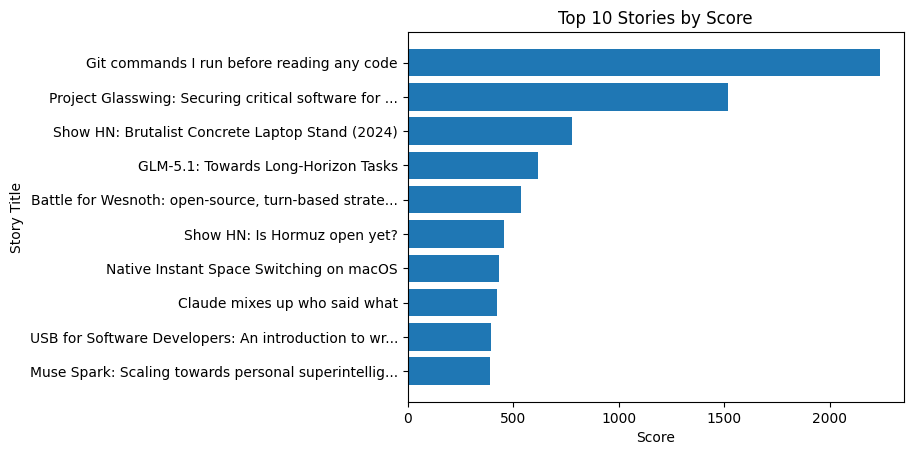

In [ ]:
# Question 4
#Chart 1: Top 10 stories by Score
import pandas as pd
import matplotlib.pyplot as plt
import os
# Creating a folder by using os library
df=pd.read_csv("data/trends_analysed.csv")
os.makedirs("outputs",exist_ok=True)
#Top 10 stories (Score) in  chart
top_10=df.sort_values(by="score",ascending=False).head(10)
top_10["short_title"] = top_10["title"].apply(
    lambda x: x[:50] + "..." if len(x) > 50 else x
)
plt.figure()
plt.barh(top_10["short_title"], top_10["score"])
plt.xlabel("Score")
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score")
plt.gca().invert_yaxis()
plt.savefig("outputs/chart1_top_stories.png")
plt.show()

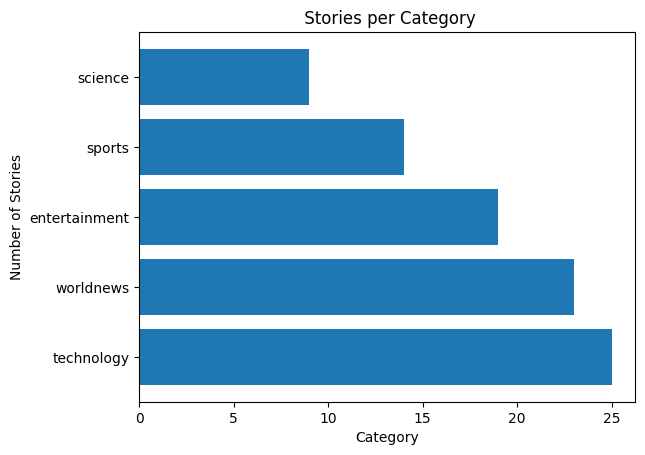

<Figure size 640x480 with 0 Axes>

In [ ]:
#Chart 2:Stories per Category
# Creating a Bar graph for Total stories in each category
category_counts=df["category"].value_counts()
plt.figure()
plt.barh(category_counts.index,category_counts.values)
plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title(" Stories per Category")
plt.show()
plt.savefig("outputs/chart2_categories.png")
plt.show()

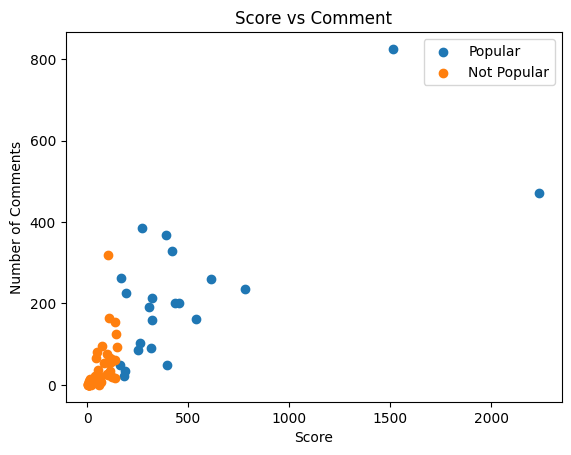

In [ ]:
# Chart3:Score vs Comments
#Creating Scatter plot
popular = df[df["is_popular"] == True]
not_popular = df[df["is_popular"] == False]
plt.figure()
plt.scatter(popular["score"], popular["num_comments"], label="Popular")
plt.scatter(not_popular["score"], not_popular["num_comments"], label="Not Popular")
plt.xlabel("Score")
plt.ylabel("Number of Comments")
plt.title("Score vs Comment")
plt.legend()
plt.savefig("outputs/chart3_score_vs_comments.png")
plt.show()
